In [ ]:
# Installations
!pip install langchain langchain-community langchain-huggingface langchain-chroma langchain-groq langchain-tavily sentence-transformers chromadb pymupdf pypdf python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/

In [ ]:
import os
import json
from dotenv import load_dotenv
import re
from typing import List, TypedDict
import time
from pydantic import BaseModel

from langchain_core.documents import Document
from langchain_community.document_loaders import PyMuPDFLoader

# Text Splitting
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Embeddings
from langchain_huggingface import HuggingFaceEmbeddings

# Vector Database
from langchain_chroma import Chroma

# LLM
from langchain_groq import ChatGroq

# Prompt Template
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph, START, END

/tmp/ipykernel_1923/555642193.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


In [ ]:
load_dotenv()
GROQ_API_KEY = os.environ['GROQ_API_KEY']
if GROQ_API_KEY is None:
  raise ValueError("GROQ_API_KEY is not set")

In [ ]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=GROQ_API_KEY
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
DATA_PATH = "/content/drive/MyDrive/RAG_Article/data"

In [ ]:
documents = []

for file in os.listdir(DATA_PATH):
    if file.endswith(".pdf"):
        loader = PyMuPDFLoader(os.path.join(DATA_PATH, file))
        documents.extend(loader.load())

print(f"Loaded {len(documents)} pages.")

Loaded 44 pages.


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

print(f"Total chunks: {len(chunks)}")

Total chunks: 41


In [ ]:
# ChromaDB Path
CHROMA_DB_DIR = "/content/drive/MyDrive/RAG_Article/chroma_db"

In [ ]:
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory=CHROMA_DB_DIR
)

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [ ]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [ ]:
class State(TypedDict):
    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_docs: List[Document]

    web_query: str

    answer: str

In [ ]:
def retrieve_node(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [ ]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output ONLY a JSON object.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

# Fixed: Added method='json_mode' for stability with gpt-oss-120b
doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore, method='json_mode')

def eval_each_doc_node(state: State) -> State:

    q = state["question"]

    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        # 5) for CORRECT case we will refine only docs with score > LOWER_TH
        if out.score > LOWER_TH:
            good.append(d)

    # 2) CORRECT if at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [ ]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output ONLY a JSON object with key 'keep'.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

# Fixed: Added method='json_mode' to fix boolean validation errors
filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop, method='json_mode')


def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:
        docs_to_use = state["good_docs"] + state["web_docs"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [ ]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return ONLY a JSON object with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

# Using json_mode to avoid tool-call validation errors with this model
rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery, method='json_mode')

def rewrite_query_node(state: State) -> State:
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State) -> State:

    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    web_docs = []
    for r in results or []:

        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")

        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"

        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}

In [ ]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
       ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

In [ ]:
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"

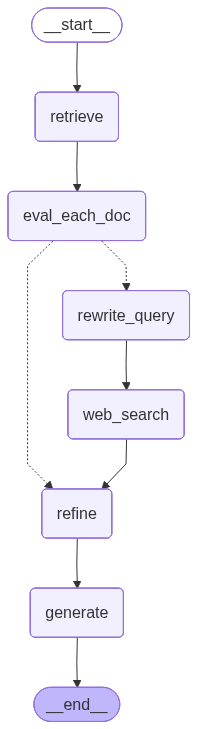

In [ ]:
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

# non-correct path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")

# correct path already goes to refine
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [ ]:
res = app.invoke(
    {
        "question": "AI news",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 **Key AI‑related headlines from the provided sources (June 2026)**  

| Date | Source | Headline & Details |
|------|--------|--------------------|
| **June 26‑27, 2026** | Crescendo AI (summary of Anthropic statement) | The U.S. Commerce Department **partially lifted export controls on Anthropic’s Claude Mythos 5**, permitting deployment to roughly **100 organizations that operate and defend critical infrastructure**. The model remains **fully suspended for general‑public users**. |
| **June 26, 2026** | OpenAI Blog | **OpenAI unveiled the GPT‑5.6 family** with three tiers: <br>• **Sol** – frontier‑reasoning model, **$5 / M input tokens, $30 / M output tokens**. <br>• **Terra** – balanced performance, **$2.50 / M input, $15 / M output**. <br>• **Luna** – speed‑optimized, **$1 / M input, $6 / M output**. |
| **June 2, 2026** | TradingView / Stocktwits (summary) | **President Trump signed an